<a href="https://colab.research.google.com/github/eshwar4202/repo/blob/main/Paper_qc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Quantum Edge detection

In [ ]:
!pip install -q qiskit qiskit-aer opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 7.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


In [ ]:
def encode_patch_amplitudes(patch):
    """
    patch: 2x2 numpy array (grayscale)
    returns: normalized amplitude vector of length 4
    """
    patch = patch.astype(float)
    s = np.sum(patch)
    if s == 0:
        patch = np.ones_like(patch)
        s = 4.0
    probs = patch.flatten() / s
    amps = np.sqrt(probs)
    return amps


In [ ]:
def normalize_patch(patch):
    patch = patch.astype(float)
    m = np.max(patch)
    if m == 0:
        return np.zeros_like(patch)
    return patch / m


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

def quantum_sobel_x_value(patch, shots=512):
    p = normalize_patch(patch)

    qc = QuantumCircuit(3, 1)  # q0,q1 = position, q2 = ancilla

    # Prepare uniform superposition over positions
    qc.h(0)
    qc.h(1)

    # Sobel-X weights:
    # left column: -1, right column: +1

    # |00>, |10>  → left
    theta_left = -np.pi * (p[0,0] + p[1,0]) / 2
    qc.cry(theta_left, 0, 2)

    # |01>, |11> → right
    theta_right = np.pi * (p[0,1] + p[1,1]) / 2
    qc.x(0)
    qc.cry(theta_right, 0, 2)
    qc.x(0)

    # Measure ancilla in Z basis
    qc.measure(2, 0)

    sim = AerSimulator()
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()

    p1 = counts.get('1', 0) / shots
    p0 = counts.get('0', 0) / shots

    return p1 - p0

In [ ]:
def quantum_sobel_y_value(patch, shots=512):
    p = normalize_patch(patch)

    qc = QuantumCircuit(3, 1)
    qc.h(0)
    qc.h(1)

    # top row: -1, bottom row: +1
    theta_top = -np.pi * (p[0,0] + p[0,1]) / 2
    qc.cry(theta_top, 1, 2)

    theta_bottom = np.pi * (p[1,0] + p[1,1]) / 2
    qc.x(1)
    qc.cry(theta_bottom, 1, 2)
    qc.x(1)

    qc.measure(2, 0)

    sim = AerSimulator()
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()

    p1 = counts.get('1', 0) / shots
    p0 = counts.get('0', 0) / shots

    return p1 - p0


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

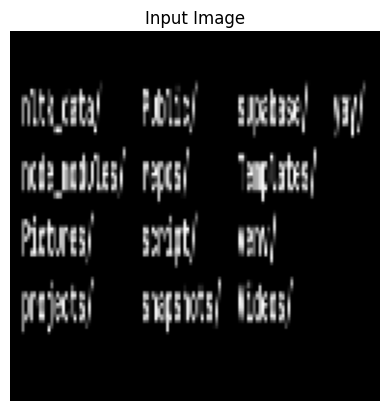

In [ ]:
# Upload your image or change the path
img = cv2.imread('/content/lena.png', cv2.IMREAD_GRAYSCALE)

# Resize for speed (recommended)
img = cv2.resize(img, (128, 128))

plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')


In [ ]:
h, w = img.shape
edges = np.zeros((h, w), dtype=float)

for y in range(h - 1):
    for x in range(w - 1):
        patch = img[y:y+2, x:x+2]

        gx = quantum_sobel_x_value(patch, shots=256)
        gy = quantum_sobel_y_value(patch, shots=256)

        # Gradient magnitude
        edges[y, x] = abs(gx) + abs(gy)


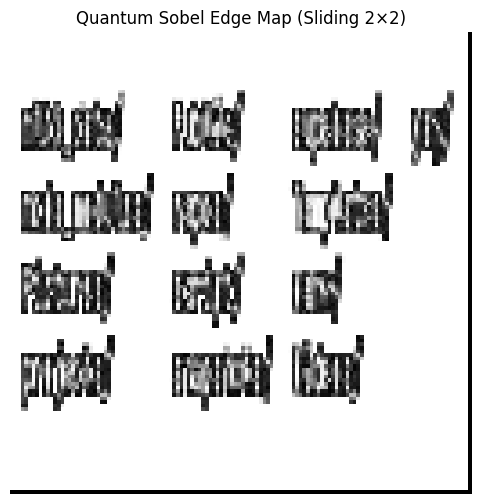

In [ ]:
sob_img = (edges - edges.min()) / (edges.max() - edges.min() + 1e-8)


plt.figure(figsize=(6,6))
plt.imshow(sob_img, cmap='gray')
plt.title("Quantum Sobel Edge Map (Sliding 2×2)")
plt.axis('off')
plt.show()


In [ ]:
def quantum_prewitt_x_value(patch, shots=512):
    p = normalize_patch(patch)

    qc = QuantumCircuit(3, 1)
    qc.h(0)
    qc.h(1)

    # Left column (negative)
    theta_left = -np.pi * (p[0,0] + p[1,0]) / 2
    qc.cry(theta_left, 0, 2)

    # Right column (positive)
    theta_right = np.pi * (p[0,1] + p[1,1]) / 2
    qc.x(0)
    qc.cry(theta_right, 0, 2)
    qc.x(0)

    qc.measure(2, 0)

    sim = AerSimulator()
    counts = sim.run(qc, shots=shots).result().get_counts()

    return (counts.get('1',0) - counts.get('0',0)) / shots


In [ ]:
def quantum_prewitt_y_value(patch, shots=512):
    p = normalize_patch(patch)

    qc = QuantumCircuit(3, 1)
    qc.h(0)
    qc.h(1)

    # Top row (negative)
    theta_top = -np.pi * (p[0,0] + p[0,1]) / 2
    qc.cry(theta_top, 1, 2)

    # Bottom row (positive)
    theta_bottom = np.pi * (p[1,0] + p[1,1]) / 2
    qc.x(1)
    qc.cry(theta_bottom, 1, 2)
    qc.x(1)

    qc.measure(2, 0)

    sim = AerSimulator()
    counts = sim.run(qc, shots=shots).result().get_counts()

    return (counts.get('1',0) - counts.get('0',0)) / shots


In [ ]:
for y in range(h - 1):
    for x in range(w - 1):
        patch = img[y:y+2, x:x+2]

        gx = quantum_prewitt_x_value(patch)
        gy = quantum_prewitt_y_value(patch)

        edges[y, x] = abs(gx) + abs(gy)


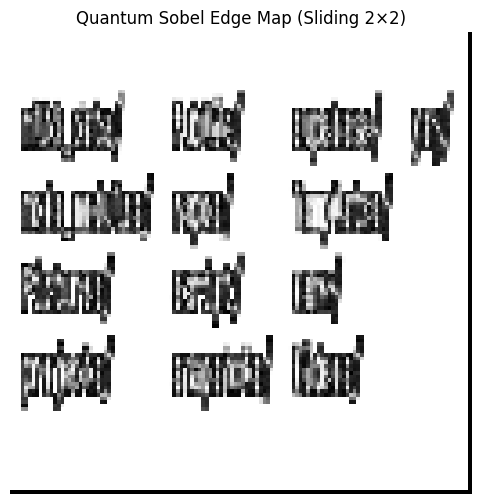

In [ ]:
pre_img = (edges - edges.min()) / (edges.max() - edges.min() + 1e-8)


plt.figure(figsize=(6,6))
plt.imshow(pre_img, cmap='gray')
plt.title("Quantum Sobel Edge Map (Sliding 2×2)")
plt.axis('off')
plt.show()


In [ ]:
def quantum_laplacian_value(patch, shots=512):
    p = normalize_patch(patch)

    qc = QuantumCircuit(3, 1)
    qc.h(0)
    qc.h(1)

    # Diagonal negative (corners)
    theta_neg = -np.pi * (p[0,0] + p[1,1]) / 2
    qc.cry(theta_neg, 0, 2)

    # Off-diagonal positive
    theta_pos = np.pi * (p[0,1] + p[1,0]) / 2
    qc.x(0)
    qc.cry(theta_pos, 0, 2)
    qc.x(0)

    qc.measure(2, 0)

    sim = AerSimulator()
    counts = sim.run(qc, shots=shots).result().get_counts()

    return (counts.get('1',0) - counts.get('0',0)) / shots


In [ ]:
edges[y, x] = abs(quantum_laplacian_value(patch))


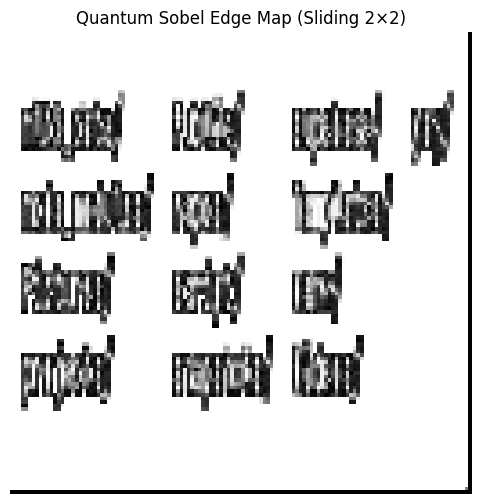

In [ ]:
lap_img = (edges - edges.min()) / (edges.max() - edges.min() + 1e-8)


plt.figure(figsize=(6,6))
plt.imshow(lap_img, cmap='gray')
plt.title("Quantum Sobel Edge Map (Sliding 2×2)")
plt.axis('off')
plt.show()


In [ ]:
def compute_mse(original, edge_map):
    """
    original : grayscale image (uint8 or float)
    edge_map : normalized edge image [0,1]
    """
    original = original.astype(float)
    edge_map = edge_map.astype(float)

    # Scale edge map to same range as original
    edge_scaled = edge_map * 255.0

    mse = np.mean((original - edge_scaled) ** 2)
    return mse


sob_mse = compute_mse(img, sob_img)
pre_mse = compute_mse(img, pre_img)
lap_mse = compute_mse(img, lap_img)
print("sobel mse", sob_mse)
print("prewitt mse", pre_mse)
print("laplacian mse", lap_mse)

sobel mse 40260.81880822468
prewitt mse 40250.821746654416
laplacian mse 40248.26536545649


In [ ]:
import numpy as np

def compute_psnr(original, edge_map):
    mse = compute_mse(original, edge_map)
    if mse == 0:
        return float('inf')
    psnr = 20 * np.log10(255.0 / np.sqrt(mse))
    return psnr

sob_psnr = compute_psnr(img, sob_img)
pre_psnr = compute_psnr(img, pre_img)
lap_psnr = compute_psnr(img, lap_img)
print("sobel psnr", sob_psnr)
print("prewitt psnr", pre_psnr)
print("laplacian psnr", lap_psnr)

sobel psnr 2.08197757720202
prewitt psnr 2.0830560966974865
laplacian psnr 2.0833319314399916


In [ ]:
def compute_noep(edge_map, threshold_ratio=0.2):
    """
    edge_map : normalized [0,1]
    threshold_ratio : fraction of max edge strength
    """
    threshold = threshold_ratio * edge_map.max()
    binary_edges = edge_map >= threshold
    return np.sum(binary_edges), binary_edges

noep_sob, binary_edges_sob = compute_noep(sob_img, threshold_ratio=0.2)
noep_pre, binary_edges_pre = compute_noep(pre_img, threshold_ratio=0.2)
noep_lap, binary_edges_lap = compute_noep(lap_img, threshold_ratio=0.2)
print("sobel noep", noep_sob)
print("prewitt noep", noep_pre)
print("laplacian noep", noep_lap)

sobel noep 14491
prewitt noep 14470
laplacian noep 14470


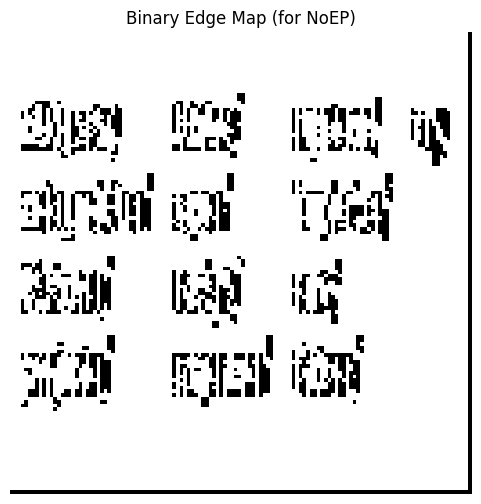

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(binary_edges_sob, cmap='gray')
plt.title("Binary Edge Map (for NoEP)")
plt.axis('off')
plt.show()


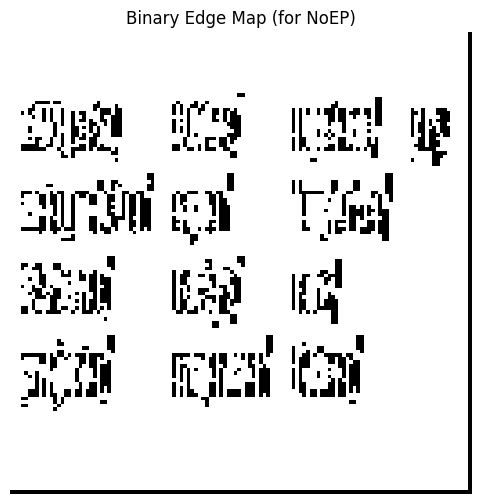

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(binary_edges_pre, cmap='gray')
plt.title("Binary Edge Map (for NoEP)")
plt.axis('off')
plt.show()


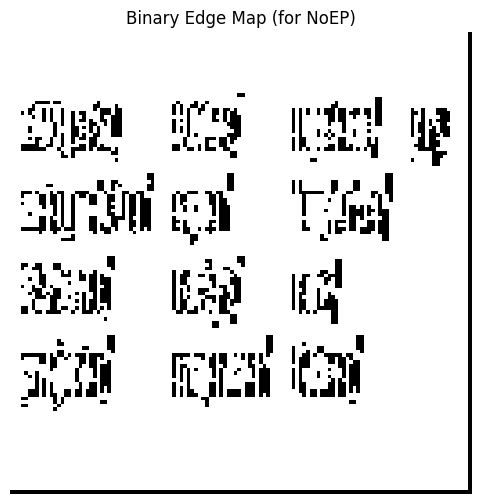

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(binary_edges_lap, cmap='gray')
plt.title("Binary Edge Map (for NoEP)")
plt.axis('off')
plt.show()
